In [4]:
%pip install matplotlib
from pathlib import Path
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_path = Path("../data/data_raw/learner01_52.wav")
y, sr = librosa.load(audio_path, sr=None)

print("Sample rate :", sr)
print("Jumlah sample:", len(y))
print("Durasi       :", len(y) / sr, "detik")


[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Sample rate : 32000
Jumlah sample: 268800
Durasi       : 8.4 detik


# Import Library

In [5]:
import librosa
import matplotlib.pyplot as plt

audio_path = Path("../data/data_raw/learner01_52.wav")

y, sr = librosa.load(audio_path, sr=None)

print(len(y), sr, len(y)/sr)

268800 32000 8.4


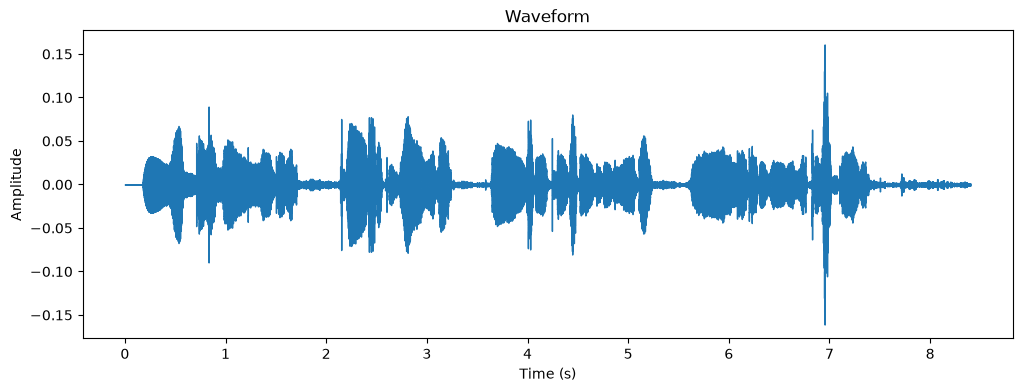

In [6]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform")

plt.show()

Durasi sebelum: 8.4
Durasi sesudah: 8.256


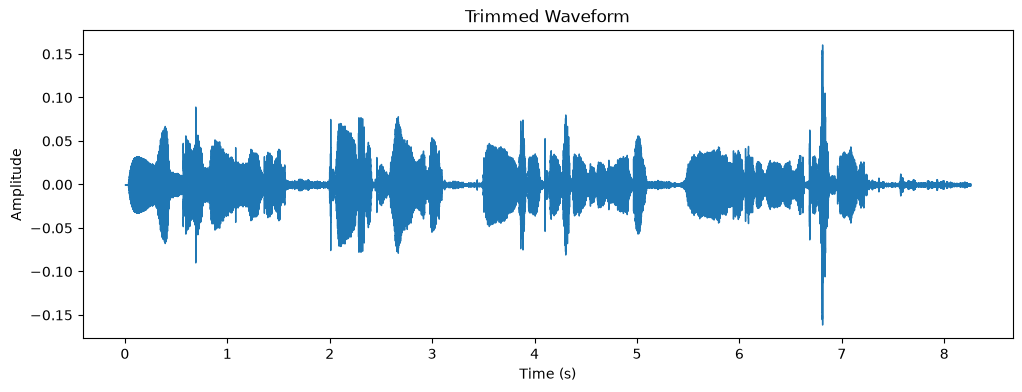

In [7]:
y_trimmed, trim_index = librosa.effects.trim(y)
print("Durasi sebelum:", len(y) / sr)
print("Durasi sesudah:", len(y_trimmed) / sr)

plt.figure(figsize=(12, 4))

librosa.display.waveshow(y_trimmed, sr=sr)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Trimmed Waveform")

plt.show()

# Resampling

In [8]:
target_sr = 16000

y_resampled = librosa.resample(
    y_trimmed,
    orig_sr=sr,
    target_sr=target_sr
)

print("Sample rate lama: ", sr) 
print("Sample rate baru: ", target_sr)
print("Durasi:", len(y_resampled)/target_sr, "detik")

Sample rate lama:  32000
Sample rate baru:  16000
Durasi: 8.256 detik


# Ekstrak F0

In [9]:
f0, voiced_flag, voiced_prob = librosa.pyin(
    y_resampled,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7")
)

In [12]:
print(f0.shape)

print(f0[:20])

(259,)
[         nan          nan          nan          nan          nan
          nan          nan          nan 169.64319079 172.60850154
 177.6663167  181.81906999 182.87233715 183.93170582 186.0688893
 179.73069986          nan 178.6955272  167.69467256 162.92073075]


## Buang NaN

In [14]:
f0_valid = f0[~np.isnan(f0)]
print("Jumlah frame:", len(f0))
print("Frame voiced:", len(f0_valid))

Jumlah frame: 259
Frame voiced: 193


## Hitung Statistik Sederhana

In [16]:
f0_mean = np.mean(f0_valid)
f0_std = np.std(f0_valid)
f0_min = np.min(f0_valid)
f0_max = np.max(f0_valid)
f0_range = f0_max - f0_min

print("F0 mean :", f0_mean)
print("F0 std  :", f0_std)
print("F0 min  :", f0_min)
print("F0 max  :", f0_max)
print("F0 range:", f0_range)

F0 mean : 150.76541102168738
F0 std  : 29.32085090546948
F0 min  : 65.40639132514966
F0 max  : 193.74649219115264
F0 range: 128.34010086600298


## Plot F0 Contour

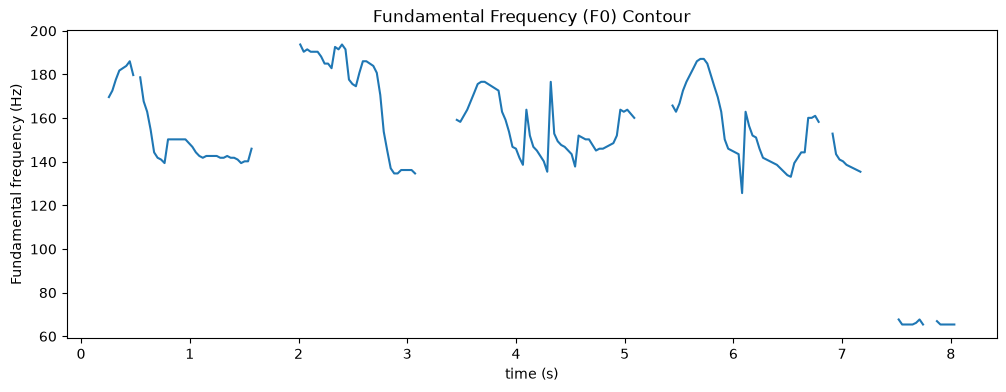

In [17]:
times = librosa.times_like(f0, sr=target_sr)
plt.figure(figsize=(12, 4))
plt.plot(times, f0)
plt.xlabel("time (s)")
plt.ylabel("Fundamental frequency (Hz)")
plt.title("Fundamental Frequency (F0) Contour")
plt.show()

[0.         0.         0.         0.         0.         0.
 0.         0.         0.01       0.01646759 0.07797524 0.07797524
 0.12793709 0.32333606 0.42606233 0.01003777 0.01       0.01000903
 0.01025905 0.01003777]


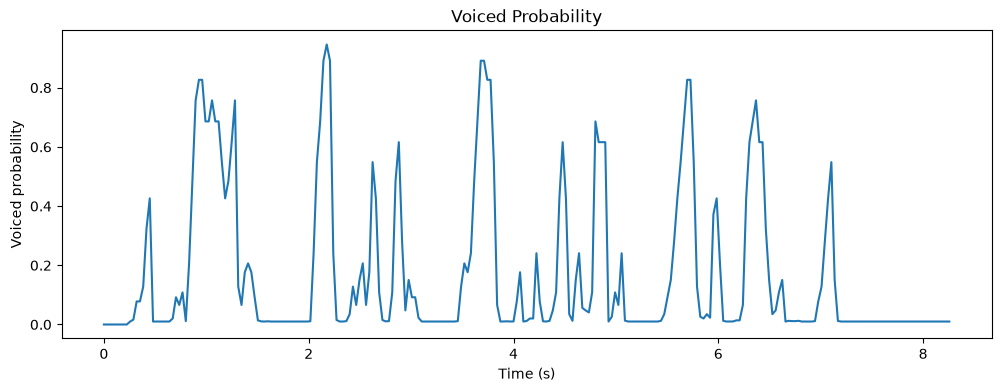

Voiced ratio: 0.7451737451737451
Voiced percentage: 74.5173745173745 %
F0 valid: 193
F0 total: 259


In [21]:
print(voiced_prob[:20])
times = librosa.times_like(f0, sr=target_sr)

plt.figure(figsize=(12, 4))

plt.plot(times, voiced_prob)

plt.xlabel("Time (s)")
plt.ylabel("Voiced probability")
plt.title("Voiced Probability")

plt.show()

voiced_ratio = np.mean(voiced_flag)

print("Voiced ratio:", voiced_ratio)
print("Voiced percentage:", voiced_ratio * 100, "%")

print("F0 valid:", len(f0_valid))
print("F0 total:", len(f0))

# Ekstrak MFCC

In [22]:
mfcc = librosa.feature.mfcc(
    y=y_resampled,
    sr=target_sr,
    n_mfcc=12
)
print(mfcc.shape)

(12, 259)


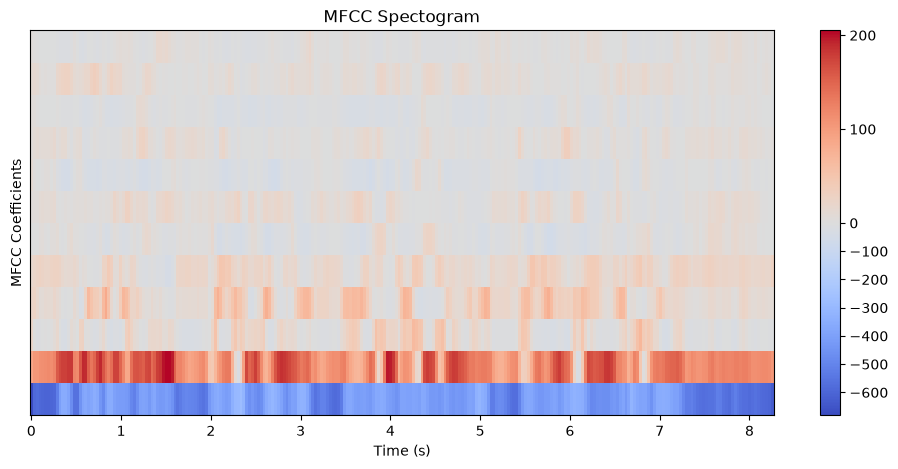

In [23]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis='time',
    sr=target_sr
)

plt.colorbar()
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.title("MFCC Spectogram")
plt.show()

In [10]:
import sys
print(sys.executable)

/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/bin/python
